# Winkansen van voetbal wedstrijden voorspellen
#### Een onderzoek van Lucas Hoetink, Hidde monsma, Gamal Al-Sabaeei

| Student | Studentennummer |
|----------|----------|
| Lucas Hoetink  | 25108263   |
| Hidde Monsma   | 25114123    |
| Gamal Al-Sabaeei   | 25023497    |


In dit rapport gaan wij de winkansen van voetbalwedstrijden voorspellen. Dit gaan we doen op basis van principes uit de data science en doormiddel van machine learning modellen. Wij gaan eerst wat onderzoek doen naar de data die ons beschikbaar is gesteld, en als wij ons daar wat bekender mee zijn geworden kunnen wij een accurate voorspelling maken.

---

### Inhoudsopgave:

[1.0 Loading Data](##1.0-loading-data)

[1.1 Classes en Functies](##1.1-classes-en-functies)

[2.0 Data Prepareren](##2.0-data-prepareren)

[3.0 Data Selecteren](##3.0-data-selecteren)

[3.1 Interessante Statestieken](##3.1-interessante-statestieken)

[3.2 Seizoen Ranglijst](##3.2-seizoen-ranglijst)

---

## Importing Libraries

Als eerste moeten we altijd de juiste libraries importeren zodat we toegang hebben tot de benodigde tools voor ons onderzoek. Libraries zoals `pandas`, `sqlite3` en `numpy` helpen ons met het vervormen en laden van data. Terwijl libaries zoals `subprocess`, `os`, en `Path` ons helpen de data op een juiste en gemakkelijke manier in te laden.

In [18]:
import sqlite3 as sql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import subprocess
import os
from pathlib import Path
import tempfile

---

## 1.0 Loading Data

Als volgende moeten we de data ophalen en inladen uit de `SQL database`.
Wij zorgen er eerst voor dat ons notebook toegang heeft tot de Kaggle API middels een api-key. Vervolgens kunnen wij via de Kaggle directory onze data tijdelijk in ons lokale geheugen inladen zodat we goed gebruik kunnen maken van de data. Wij hebben gekozen voor deze aanpak om de druk op de server te verkleinen, en geen grote databases altijd ingeladen te hebben in de repository.

In [19]:
subprocess.run(['pip', 'install', 'kaggle', '-q'], capture_output=True)

# Kaggle-referenties instellen
kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)
# If the directory already exists: don't throw an error, just continue

credentials = {
    "username": "lucashoetink",
    "key": "22e34cd52b72413f58087cacec1636c7"
}

with open(kaggle_dir / 'kaggle.json', 'w') as f:
    json.dump(credentials, f)

# Change mode to 0o600 = read/write for the user only
# 6 (owner/user): read (4) + write (2) = 6
# 0 (group): no permissions
# 0 (others/world): no permissions
os.chmod(kaggle_dir / 'kaggle.json', 0o600)

# Downloaden naar een schrijfbare tijdelijke map
temp_dir = tempfile.gettempdir()

# call the kaggle API to download and unzip the dataset to the temporary directory
os.system(f'kaggle datasets download -d hugomathien/soccer --unzip -p {temp_dir}')

# Verbinding met de database vanuit tijdelijke map
db_path = os.path.join(temp_dir, 'database.sqlite')
connection = sql.connect(db_path)
print(f"Connected to database at: {db_path}")

Dataset URL: https://www.kaggle.com/datasets/hugomathien/soccer
License(s): ODbL-1.0


100%|█████████████████████████████████████| 32.7M/32.7M [00:02<00:00, 14.8MB/s]



Connected to database at: /var/folders/jl/9dx0t8f14zxgdhb7jmsg80wh0000gn/T/database.sqlite


---

## 1.1 Classes en Functies

Om de data efficient en overzichtelijk te kunnen behandelen maken wij gebruik van python classes. Binnen deze classes kunnen we de juiste informatie makkelijk en overzichtelijk inladen.
Voor dit onderzoek heben wij momenteel 2 classes staan. Als eerste een Club class om data over clubs in te laden en te onderzoeken met methodes om bijvoorbeeld gemiddelde speler statestieken te krijgen. Als tweede hebben wij een Research class staan die het onderzoek zal bevoorderen. Hierin kunnen wij functies stoppen om te werken met de club class om dingen zoals ranglijsten en seizoens correlaties op een rijtje te zetten.

In [20]:
class Club():
    """
        Description: 
            Deze class representeert een voetbalclub. Het bevat informatie over de club en DataFrames voor spelers en wedstrijden.
        
        Attributes:
            team_id: id van de club.
            team_name: De naam van de club.
            matches_df: DataFrame met wedstrijden van de club.
            
         Methods:
            load_matches(matches_df): 
                Laadt wedstrijden van de club als DataFrame.
            get_season_matches(season): 
                Haalt wedstrijden van een bepaald seizoen.
            calculate_season_stats(season): 
                Berekent statistieken voor het team voor het gegeven seizoen.
            get_player_stats(): 
                Berekent gemiddelde en categorische statistieken voor spelers van het team.
    """
    
    def __init__(self, team_id, team_name):
        """
            Description:
                De constructor van de Club class.
                
            Args:
                team_id: id van de club.
                team_name: De naam van de club.
                
            Returns:
                None
            
        """
        self.team_id = team_id
        self.team_name = team_name
        self.matches_df = pd.DataFrame()
        
    def load_matches(self, matches_df):
        """
            Description:
                Laadt alle wedstrijden van deze club uit een matches DataFrame.
                
            Args:
                matches_df: Een DataFrame met alle wedstrijden.
                
            Returns:
                None
        """
        club_matches = matches_df[(matches_df['home_team_api_id'] == self.team_id) | (matches_df['away_team_api_id'] == self.team_id)].copy()
        self.matches_df = club_matches
        
    def get_season_matches(self, season):
        """
            Description:
                Haalt alle wedstrijden van een bepaald seizoen.
                
            Args:
                season: Het seizoen (bijv. '2015/2016').
                
            Returns:
                DataFrame met wedstrijden van dat seizoen.
        """
        return self.matches_df[self.matches_df['season'] == season]
    
    def calculate_season_stats(self, season=None):
        """
            Description:
                Berekent statistieken voor het team in een bepaald seizoen.
                
            Args:
                season: Het seizoen (optioneel). Als None, alle seizoenen.
                
            Returns:
                Dictionary met statistieken.
        """
        if season:
            matches = self.get_season_matches(season)
        else:
            matches = self.matches_df
        
        if len(matches) == 0:
            return {}
        
        wins = len(matches[
            ((matches['home_team_api_id'] == self.team_id) & (matches['home_team_goal'] > matches['away_team_goal'])) |
            ((matches['away_team_api_id'] == self.team_id) & (matches['away_team_goal'] > matches['home_team_goal']))
        ])
        
        draws = len(matches[matches['home_team_goal'] == matches['away_team_goal']])
        losses = len(matches) - wins - draws
        
        goals_for = matches[matches['home_team_api_id'] == self.team_id]['home_team_goal'].sum() + \
                    matches[matches['away_team_api_id'] == self.team_id]['away_team_goal'].sum()
        
        goals_against = matches[matches['home_team_api_id'] == self.team_id]['away_team_goal'].sum() + \
                        matches[matches['away_team_api_id'] == self.team_id]['home_team_goal'].sum()
        
        points = (wins * 3) + (draws * 1)
        
        return {
            'club': self.team_name,
            'wins': wins,
            'draws': draws,
            'losses': losses,
            'goals_for': goals_for,
            'goals_against': goals_against,
            'goal_difference': goals_for - goals_against,
            'points': points,
            'matches_played': len(matches)
        }

    def get_player_stats(self):
        """
            Description:
                Berekent gemiddelde en categorische statistieken voor spelers van het team.
                
            Returns:
                DataFrame met numerieke gemiddelden en categorische waarde tellingen.
        """
        matches = self.matches_df
            
        # Vind alle spelers die in dit seizoen hebben gespeeld in deze club
        home_players = matches[matches['home_team_api_id'] == self.team_id][['home_player_1', 'home_player_2', 'home_player_3', 'home_player_4', 'home_player_5', 'home_player_6', 'home_player_7', 'home_player_8', 'home_player_9', 'home_player_10', 'home_player_11']]
        away_players = matches[matches['away_team_api_id'] == self.team_id][['away_player_1', 'away_player_2', 'away_player_3', 'away_player_4', 'away_player_5', 'away_player_6', 'away_player_7', 'away_player_8', 'away_player_9', 'away_player_10', 'away_player_11']]     
        
        player_ids = pd.concat([home_players.stack(), away_players.stack()]).unique()
        
        global player_attributes
        
        def get_player_stats(player_id):
            player_data = player_attributes[player_attributes['player_api_id'] == player_id].drop(columns=['date'])
            return player_data.iloc[0]
        
        total_stats = []
        
        for player_id in player_ids:
            stats = get_player_stats(player_id)
            total_stats.append(stats)
        
        stats_df = pd.DataFrame(total_stats)
        
        # Bereken numerieke gemiddelden
        numeric_stats = stats_df.select_dtypes(include=[np.number]).mean().round(2).to_dict()
        
        # Bereken categorische waardetellers en breid uit naar aparte kolommen
        categorical_cols = stats_df.select_dtypes(include=['object']).columns
        categorical_stats = {}
        
        for col in categorical_cols:
            value_counts = stats_df[col].value_counts().to_dict()
            for value, count in value_counts.items():
                categorical_stats[f'{col}_{value}'] = count
        
        # Combineer resultaten in één rij
        result = {**numeric_stats, **categorical_stats}
        result_df = pd.DataFrame([result])
        
        return result_df.drop(columns=['id','player_api_id', 'player_fifa_api_id'], errors='ignore')
        
class Research():
    """
        Description:
            Deze class bevat methoden voor het uitvoeren van onderzoek en analyses op de club data.
        
        Methods:
            season_correlation_analysis(club, season): 
                Voert een correlatieanalyse uit op de performance van het team in een seizoen.
                
            get_season_ranking(matches_df, season, league_id):
                Geeft de ranglijst van alle teams voor een seizoen.    
    """
    
    def __init__(self, connection):
        self.connection = connection
          
    def season_correlation_analysis(self, season):
        """
            Description:
                Voert een correlatieanalyse uit op de performance van het team in een seizoen.
                Combineert team statistieken met speler statistieken en berekent correlaties met punten.
                
            Args:
                season: Het seizoen om te analyseren.
                
            Returns:
                DataFrame met correlaties gesorteerd op absolute correlatiewaarde.
        """
        global matches, teams
        
        season_matches = matches[matches['season'] == season].copy()
        
        data = []
        
        for team in season_matches['home_team_api_id'].unique():
            club = Club(team_id=team, team_name=teams.loc[teams['team_api_id'] == team, 'team_long_name'].values[0])
            club.load_matches(matches)
            
            # Teamstatistieken ophalen
            team_stats = club.calculate_season_stats(season)
            
            # Spelerstatistieken ophalen
            player_stats_df = club.get_player_stats()
            player_stats = player_stats_df.iloc[0].to_dict() if not player_stats_df.empty else {}
            
            # Combineer team- en spelerstatistieken in één rij
            combined_stats = {**team_stats, **player_stats}
            data.append(combined_stats)
        
        # Converteer naar DataFrame
        analysis_df = pd.DataFrame(data)
        
        # Bereken correlaties met punten
        if 'points' not in analysis_df.columns:
            print("'points' column not found in data")
            return pd.DataFrame()
        
        correlations = []
        numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            if col != 'points':  # Correleer punten niet met zichzelf
                # Sla kolommen met nul-variantie over (voorkomt deling door nul waarschuwing)
                if analysis_df[col].std() == 0:
                    continue
                
                corr_value = round(analysis_df[col].corr(analysis_df['points']), 2)
                if pd.notna(corr_value):
                    correlations.append({
                        'variable': col,
                        'correlation_with_points': corr_value
                    })
        
        # Creëer correlatie DataFrame gesorteerd op absolute correlatie
        correlation_df = pd.DataFrame(correlations).sort_values(
            'correlation_with_points', 
            ascending=False, 
            key=abs
        ).reset_index(drop=True)
        
        # Verwijder irrelevante variabelen die meer direct uit punten zijn berekend
        irrelevant_vars = ['wins', 'goal_difference', 'goals_for', 'goals_against', 'matches_played', 'draws', 'losses']
        return correlation_df[~correlation_df['variable'].isin(irrelevant_vars)]
    
    def get_season_ranking(self, matches_df, season, league_id=None):
        """
            Description:
                Geeft de ranglijst van alle teams voor een bepaald seizoen en competitie.
                
            Args:
                matches_df: DataFrame met alle wedstrijden.
                season: Het seizoen om te analyseren.
                league_id: Optionele league_id.
                
            Returns:
                DataFrame met ranglijst gesorteerd op punten.
        """
        season_matches = matches_df[matches_df['season'] == season].copy()
        
        global teams
        
        if league_id:
            season_matches = season_matches[season_matches['league_id'] == league_id]
        
        if season_matches.empty:
            print(f'Geen matches gevonden voor season {season}.')
            return pd.DataFrame()
        
        season_stats_list = []
        
        for team in season_matches['home_team_api_id'].unique():
            club = Club(team_id=team, team_name=teams.loc[teams['team_api_id'] == team, 'team_long_name'].values[0])
            club.load_matches(matches_df)
            stats = club.calculate_season_stats(season)
            season_stats_list.append(stats)
        
        season_stats = pd.DataFrame(season_stats_list)
        ranking_df = season_stats.sort_values('points', ascending=False).reset_index(drop=True)
        
        return ranking_df
    
    def sql_to_df(self, query):
        """
            Description:
                Voert een SQL-query uit op de database en retourneert het resultaat als een DataFrame.
                
            Args:
                query: De SQL-query om uit te voeren.
                
            Returns:
                DataFrame met queryresultaten.
        """
        return pd.read_sql_query(query, self.connection)

---

## 2.0 Data Prepareren

Hier gaan we de relevante tabellen uit SQL halen en inladen in PandasDataframes om het te effectief te kunnen gebruiken.


In [21]:
teams = pd.read_sql("""
                 SELECT * 
                 FROM Team
                 """, connection)

team_attributes = pd.read_sql("""
                 SELECT * 
                 FROM Team_attributes
                 """, connection)

matches = pd.read_sql("""
                 SELECT * 
                 FROM Match
                 ---WHERE season = '2009/2010' AND league_id = 13274
                 """, connection)

matches.drop(columns=
             ['home_player_X1', 'home_player_X2', 'home_player_X3', 'home_player_X4', 'home_player_X5', 'home_player_X6', 'home_player_X7', 'home_player_X8', 'home_player_X9', 'home_player_X10', 'home_player_X11', 'away_player_X1', 'away_player_X2', 'away_player_X3', 'away_player_X4', 'away_player_X5', 'away_player_X6', 'away_player_X7', 'away_player_X8', 'away_player_X9', 'away_player_X10', 'away_player_X11', 'home_player_Y1', 'home_player_Y2', 'home_player_Y3', 'home_player_Y4', 'home_player_Y5', 'home_player_Y6', 'home_player_Y7', 'home_player_Y8', 'home_player_Y9', 'home_player_Y10', 'home_player_Y11', 'away_player_Y1', 'away_player_Y2', 'away_player_Y3', 'away_player_Y4', 'away_player_Y5', 'away_player_Y6', 'away_player_Y7', 'away_player_Y8', 'away_player_Y9', 'away_player_Y10', 'away_player_Y11', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'], inplace=True)

league = pd.read_sql("""
                 SELECT * 
                 FROM League
                 """, connection)

league_index = {id: name for id, name in zip(league['id'], league['name'])}

players = pd.read_sql("""
                 SELECT * 
                 FROM Player
                 """, connection)

player_attributes = pd.read_sql("""
                 SELECT * 
                 FROM Player_Attributes
                 """, connection)

Elk van deze tabellen hebben kolommen die overeen komen met andere kolommen in andere tabellen. Deze kolommen worden Key Identifiers genoemd. Een key Identifier is een kolom die alleen unieke waardes heeft, zodat via andere tabellen hiernaartoe gerefereerd kan worden. Ook staan de zogenaamde linking identifiers beschreven die verschillende tabellen met elkaar linken. Dat zijn dus kolommen met waardes tussen tabellen die overeenkomen.

|  | Match | League | Player | Team | Country | Player_Attributes | Team_Attributes |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| KEY IDENTIFIERS | id | id | id | id | id | id | id |
| LINKING IDENTIFIERS | country_id, league_id, home_team_api_id, away_team_api_id, home_player_1, away_player_1 | country_id | player_api_id | team_api_id |  | player_api_id | team_api_id |

![image](https://image2url.com/r2/default/images/1774357157005-494aef16-cae3-4af7-86a7-ac5f1dbf074c.png)

---

## 3.0 Data Selecteren

Voor dit onderzoek gaan we op zoek naar de statestieken van de club Sparta in het seizoen 2009/2010. Wij hebben voor het gemakkelijk en overzichtelijk inladen van functies verschillende classes en functies ontworpen. Wij hebben ook de Key Identifiers van ons gekozen seizoen, club, divisie, etc. op een rijtje gezet.

In [22]:
# Research-object aanmaken met gestructureerde klassen
Onderzoek = Research(connection)

sparta_info = teams.loc[teams['team_long_name'] == 'Sparta Rotterdam']

sparta_id = sparta_info['team_api_id'].values[0]
sparta_naam = sparta_info['team_long_name'].values[0]

# Initialiseer Club-instantie
Sparta = Club(team_id=sparta_id, team_name=sparta_naam)
Sparta.load_matches(matches)

# Toon identifiers van Sparta Rotterdam
data = {
    'Type Identifier': [
        'Club Naam (Lang)', 
        'Club Naam (Kort)', 
        'Team API ID', 
        'Team FIFA ID', 
        'League ID', 
        'Country ID', 
        'Team Attribute ID '
    ],
    'Waarde': [
        'Sparta Rotterdam', 
        'SPA', 
        8614, 
        1006, 
        13274, 
        13274, 
        1202
    ],
}

df_identifiers = pd.DataFrame(data)

display(df_identifiers)

,Type Identifier,Waarde
0,Club Naam (Lang),Sparta Rotterdam
1,Club Naam (Kort),SPA
2,Team API ID,8614
3,Team FIFA ID,1006
4,League ID,13274
5,Country ID,13274
6,Team Attribute ID,1202


---

## 3.1 Interessante Statestieken

Hier doen wij onderzoek naar de statestieken van een gekozen seizoen en laten zien hoe verschillende aspecten van een team effect hebben op de uitkomst can een match en de plaatsing in een seizoen. Effectief onderzoeken we dus welke aspecten van een Club het meest effect hebben op hoe veel punten ze krijgen in een seizoen.

In [23]:
# Gebruik de Research class om correlatieanalyse uit te voeren voor seizoen 2009/2010
correlations = Onderzoek.season_correlation_analysis(season='2009/2010')
print("Correlatie analyse voor seizoen 2009/2010:")
print("\nTop 10 meest correlerende factoren:")
display(correlations.head(10))

Correlatie analyse voor seizoen 2009/2010:

Top 10 meest correlerende factoren:


,variable,correlation_with_points
4,defensive_work_rate_9,-0.61
6,potential,0.56
7,dribbling,0.56
8,short_passing,0.55
9,long_passing,0.53
10,overall_rating,0.53
11,agility,0.53
12,ball_control,0.53
13,vision,0.51
14,positioning,0.50


---

## 3.2 Seizoen Ranglijst

We kunnen middels onze onderzoek class ook een ranglijst laten zien van alle wedstrijden in een bepaalde divisie en seizoen. Hier hebben we voor de Eredevisie in het seizoen 2009/2010 de ranglijst laten zien.

In [24]:
# Display de ranglijst van alle teams voor seizoen 2009/2010 in de eredivisie (league_id 13274)
display(Onderzoek.get_season_ranking(matches, season='2009/2010', league_id=13274))

,club,wins,draws,losses,goals_for,goals_against,goal_difference,points,matches_played
0,FC Twente,27,5,2,63,23,40,86,34
1,Ajax,27,4,3,106,20,86,85,34
2,PSV,23,9,2,72,29,43,78,34
3,Feyenoord,17,12,5,54,31,23,63,34
4,AZ,19,5,10,64,34,30,62,34
5,Heracles Almelo,17,5,12,54,49,5,56,34
6,FC Utrecht,14,11,9,39,33,6,53,34
7,FC Groningen,14,7,13,48,47,1,49,34
8,Roda JC Kerkrade,14,5,15,56,60,-4,47,34
9,NAC Breda,12,10,12,42,49,-7,46,34


---

# Sprint 3

---

## 4.1 SQL Tabellen

Wij gaan hier middels SQL en onze onderzoeks klasse verschillende tabellen genereren om de volgende vragen te beantwoorden:

1. Het aantal wedstrijden dat Sparta heeft gespeeld per seizoen.
2. Het aantal wedstrijden van Sparta in het kalenderjaar 2010 per seizoen.
3. Toon hoeveel punten ieder team in de eredivisie gehaald heeft per seizoen.
4. Op welke plaats Sparta daarmee is geëindigd in de ranglijst.

Uiterraard is ons onderzoek voor Sparta Rotterdam, maar wij hebben een functie opgezet om ook de statestieken te krijgen voor andere clubs!

In [25]:
def antwoorden_vragen(team_naam, league_naam, jaar, export_points = False):
    '''
        Description:
            Deze functie beantwoordt de volgende vragen over het team met team_id in de competitie met league_id voor het kalenderjaar jaar:
            1. Het aantal wedstrijden dat Sparta heeft gespeeld per seizoen.
            2. Het aantal wedstrijden van Sparta in het kalenderjaar 2010 per seizoen.
            3. Toon hoeveel punten ieder team in de eredivisie gehaald heeft per seizoen.
            4. Op welke plaats Sparta daarmee is geëindigd in de ranglijst. 
        
        Args:
            team_id: De API ID van het team (Sparta Rotterdam).
            league_id: De ID van de competitie (Eredivisie).
            jaar: Het kalenderjaar om te analyseren (2010).
    '''
    
    team_id = teams[teams['team_long_name'] == team_naam]['team_api_id'].values[0]
    league_id = league[league['name'] == league_naam]['id'].values[0]
    
    # 1. Het aantal wedstrijden dat Sparta heeft gespeeld per seizoen.
    df_1 = Onderzoek.sql_to_df(f"""
        SELECT season, COUNT(*) AS aantal_wedstrijden
        FROM Match
        WHERE home_team_api_id = {team_id} OR away_team_api_id = {team_id}
        GROUP BY season
        ORDER BY season;
    """)

    # 2. Het aantal wedstrijden van Sparta in het kalenderjaar 2010 per seizoen.
    df_2 = Onderzoek.sql_to_df(f"""
        SELECT season, COUNT(*) AS aantal_wedstrijden
        FROM Match
        WHERE (home_team_api_id = {team_id} OR away_team_api_id = {team_id})
        AND strftime('%Y', date) = '{jaar}'
        GROUP BY season 
        ORDER BY season;
    """)

    # 3. Toon hoeveel punten ieder team in de eredivisie gehaald heeft per seizoen.
    df_3 = Onderzoek.sql_to_df(f"""
        SELECT T.team_long_name, punten.season, punten.points
        FROM (
            SELECT home_team_api_id AS team_api_id, season,
                SUM(CASE 
                    WHEN home_team_goal > away_team_goal THEN 3
                    WHEN home_team_goal = away_team_goal THEN 1
                    ELSE 0
                END) AS points
            FROM Match
            WHERE league_id = {league_id}
            GROUP BY season, home_team_api_id
            UNION ALL
            SELECT away_team_api_id AS team_api_id, season,
                SUM(CASE 
                    WHEN away_team_goal > home_team_goal THEN 3
                    WHEN away_team_goal = home_team_goal THEN 1
                    ELSE 0
                END) AS points
            FROM Match
            WHERE league_id = {league_id}
            GROUP BY season, away_team_api_id
        ) AS punten
        JOIN Team AS T USING (team_api_id)
        ORDER BY season, points DESC;
    """)

    # 4. Op welke plaats Sparta daarmee is geëindigd in de ranglijst.
    df_4 = Onderzoek.sql_to_df(f"""
        WITH TeamPunten AS (
            
            SELECT home_team_api_id AS team_api_id, season,
                SUM(CASE 
                    WHEN home_team_goal > away_team_goal THEN 3
                    WHEN home_team_goal = away_team_goal THEN 1
                    ELSE 0
                END) AS punten
            FROM Match
            WHERE league_id = {league_id}
            GROUP BY season, home_team_api_id
            
            UNION ALL
            
            SELECT away_team_api_id AS team_api_id, season,
                SUM(CASE 
                    WHEN away_team_goal > home_team_goal THEN 3
                    WHEN away_team_goal = home_team_goal THEN 1
                    ELSE 0
                END) AS punten
            FROM Match
            WHERE league_id = {league_id}
            GROUP BY season, away_team_api_id
        ),
        TeamsRanglijst AS (
            SELECT team_api_id, season, punten,
                RANK() OVER (
                    PARTITION BY season 
                    ORDER BY punten DESC
                    ) AS rank
            FROM TeamPunten
        )
        SELECT T.team_long_name, R.season, R.punten, R.rank
        FROM TeamsRanglijst R
        JOIN Team T ON R.team_api_id = T.team_api_id
        WHERE R.team_api_id = {team_id}
        GROUP BY R.season
        ORDER BY R.season;
    """)
    
    if export_points:
        return df_3
    else:
        print('- - - '*20)
        print('------'*20)
        print(f'1. Het aantal wedstrijden dat {team_naam} heeft gespeeld per seizoen.')
        display(df_1)
        print('------'*20)
        print(f'2. Het aantal wedstrijden van {team_naam} in het kalenderjaar 2010 per seizoen.')
        display(df_2)
        print('------'*20)
        print(f'3. Toon hoeveel punten ieder team in de eredivisie gehaald heeft per seizoen.')
        display(df_3)
        print('------'*20)
        print(f'4. Op welke plaats {team_naam} daarmee is geëindigd in de ranglijst.')
        display(df_4)
        print('------'*20)
    
# Sparta Rotterdam
antwoorden_vragen(team_naam='Sparta Rotterdam', league_naam='Netherlands Eredivisie', jaar='2010')
print('Helaas is Sparta in het seizoen 2009/2010 gedegradeerd, waardoor zij niet verdere wedstrijden hebben kunnen spelen.')
print('------'*20)

# Ajax
antwoorden_vragen(team_naam = 'Ajax', league_naam='Netherlands Eredivisie', jaar='2010')

# AZ
antwoorden_vragen(team_naam = 'AZ', league_naam='Netherlands Eredivisie', jaar='2010')

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
------------------------------------------------------------------------------------------------------------------------
1. Het aantal wedstrijden dat Sparta Rotterdam heeft gespeeld per seizoen.


,season,aantal_wedstrijden
0,2008/2009,34
1,2009/2010,34


------------------------------------------------------------------------------------------------------------------------
2. Het aantal wedstrijden van Sparta Rotterdam in het kalenderjaar 2010 per seizoen.


,season,aantal_wedstrijden
0,2009/2010,16


------------------------------------------------------------------------------------------------------------------------
3. Toon hoeveel punten ieder team in de eredivisie gehaald heeft per seizoen.


...

------------------------------------------------------------------------------------------------------------------------
3. Toon hoeveel punten ieder team in de eredivisie gehaald heeft per seizoen.


,team_long_name,season,points
0,AZ,2008/2009,43
1,Ajax,2008/2009,42
2,FC Twente,2008/2009,40
3,SC Heerenveen,2008/2009,38
4,PSV,2008/2009,37
...,...,...,...
283,Excelsior,2015/2016,13
284,SC Cambuur,2015/2016,11
285,N.E.C.,2015/2016,11
286,De Graafschap,2015/2016,8


------------------------------------------------------------------------------------------------------------------------
4. Op welke plaats AZ daarmee is geëindigd in de ranglijst.


,team_long_name,season,punten,rank
0,AZ,2008/2009,43,1
1,AZ,2009/2010,35,6
2,AZ,2010/2011,35,6
3,AZ,2011/2012,43,2
4,AZ,2012/2013,20,20
5,AZ,2013/2014,35,4
6,AZ,2014/2015,32,5
7,AZ,2015/2016,32,8


------------------------------------------------------------------------------------------------------------------------


---

## 4.2 Data klaarmaken voor analyse

In [26]:
punten_df = antwoorden_vragen(team_naam = 'Sparta Rotterdam', league_naam='Netherlands Eredivisie', jaar='2010', export_points=True)

## Data visualisation : 


In [27]:
# Gebruik de Research class om correlatieanalyse uit te voeren voor seizoen 2009/2010
correlations = Onderzoek.season_correlation_analysis(season='2009/2010')
print("Correlatie analyse voor seizoen 2009/2010:")
print("\nTop 10 meest correlerende factoren:")
display(correlations.head(10))

Correlatie analyse voor seizoen 2009/2010:

Top 10 meest correlerende factoren:


,variable,correlation_with_points
4,defensive_work_rate_9,-0.61
6,potential,0.56
7,dribbling,0.56
8,short_passing,0.55
9,long_passing,0.53
10,overall_rating,0.53
11,agility,0.53
12,ball_control,0.53
13,vision,0.51
14,positioning,0.50


/var/folders/jl/9dx0t8f14zxgdhb7jmsg80wh0000gn/T/ipykernel_12904/3743429029.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


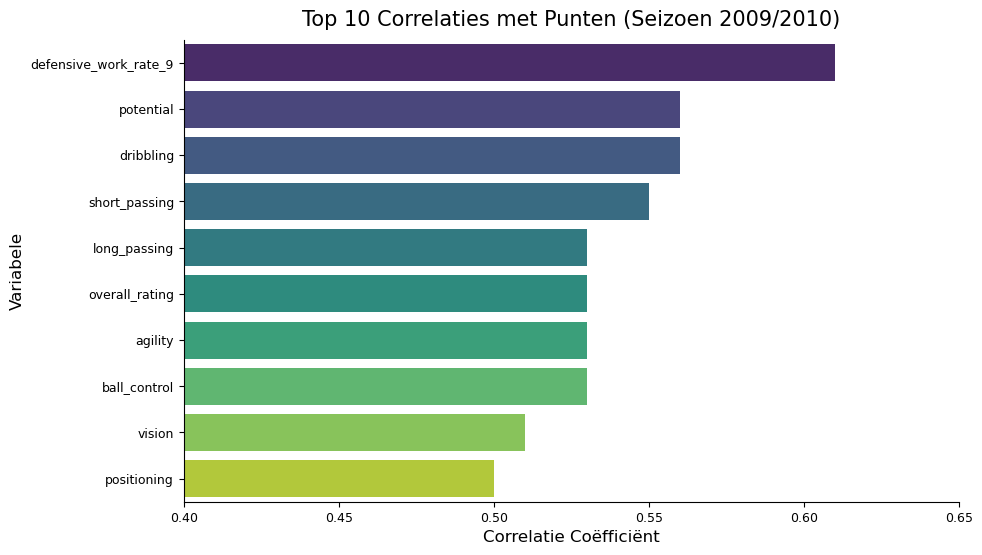

In [28]:
df_plot = correlations.copy()
df_plot['abs_correlation'] = df_plot['correlation_with_points'].abs()

df_plot = df_plot.sort_values('abs_correlation', ascending=False).head(10)

df_plot = df_plot.sort_values('abs_correlation', ascending=False)

plt.figure(figsize=(10, 6))

colors = ['blue' if x > 0 else 'red' for x in df_plot['correlation_with_points']]
sns.barplot(
    x='abs_correlation', 
    y='variable', 
    data=df_plot, 
    palette='viridis')

plt.title('Top 10 Correlaties met Punten (Seizoen 2009/2010)', fontsize=15)
plt.xlabel('Correlatie Coëfficiënt', fontsize=12)
plt.ylabel('Variabele', fontsize=12)
plt.axvline(0, color='black', lw=1) 
plt.xlim(0.4, 0.65)


plt.show()



# Beschrijving: 
De visualisatie laat zien welke spelerskenmerken in het seizoen 2009/2010 het sterkst samenhangen met het aantal behaalde punten. Bovenaan staat defensive_work_rate, met de hoogste correlatie. Dit betekent dat spelers die een hoge verdedigende inzet hebben, gemiddeld meer punten behalen. Daarna volgen potential en dribbling, wat aangeeft dat zowel het ontwikkelingspotentieel als technische vaardigheid belangrijke factoren zijn voor succes.
Ook short_passing en long_passing spelen een duidelijke rol, wat suggereert dat goede passingvaardigheden bijdragen aan het creëren van kansen en dus aan het scoren van punten. Verder zien we dat overall_rating, agility en ball_control een vergelijkbare, middelsterke correlatie hebben. Dit wijst erop dat algemene kwaliteit en wendbaarheid eveneens belangrijk zijn, maar iets minder doorslaggevend dan de eerder genoemde factoren.
Onderaan staan vision en positioning, met de laagste correlaties binnen de top 10. Hoewel deze eigenschappen nog steeds een positieve relatie hebben met punten, is hun invloed relatief kleiner.
Samengevat toont de grafiek dat vooral verdedigende inzet, potentieel en technische vaardigheden zoals dribbelen en passen de grootste bijdrage leveren aan het behalen van punten, terwijl inzicht en positionering een meer ondersteunende rol spelen.

---

## 5.0 Visualisaties

In deze sectie voegen we extra visualisaties toe om de data beter te begrijpen. We bekijken:
- De ranglijst van de Eredivisie 2009/2010 als een staafdiagram
- De verdeling van doelpunten (voor en tegen) per team
- Een win/gelijkspel/verlies-analyse per team
- Correlatieheatmap van teamattributen
- Spelersrating versus behaalde punten (scatter + regressie)
- Doelsaldo versus punten
- Vergelijking van top-attributen: categorische én numerieke variabelen


In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

# ── Globale stijl ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'axes.labelsize':    10,
    'axes.titlesize':    11,
    'axes.titlepad':     10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'font.family':       'sans-serif',
    'legend.frameon':    False,
})

BLUE   = '#2563EB'
RED    = '#EF4444'
GREEN  = '#22C55E'
ORANGE = '#F97316'
GREY   = '#94A3B8'
FILL   = '#E2E8F0'

print('Stijl ingesteld.')

Stijl ingesteld.


### 5.1 Eredivisie Eindstand 2009/2010

Het staafdiagram hieronder toont de eindstand van de Eredivisie in het seizoen 2009/2010, gesorteerd op punten. Sparta Rotterdam staat onderaan, wat overeenkomt met hun degradatie dat jaar.
De drie bovenste clubs (FC Twente, Ajax, PSV) vormen duidelijk een kopgroep met meer dan 75 punten.

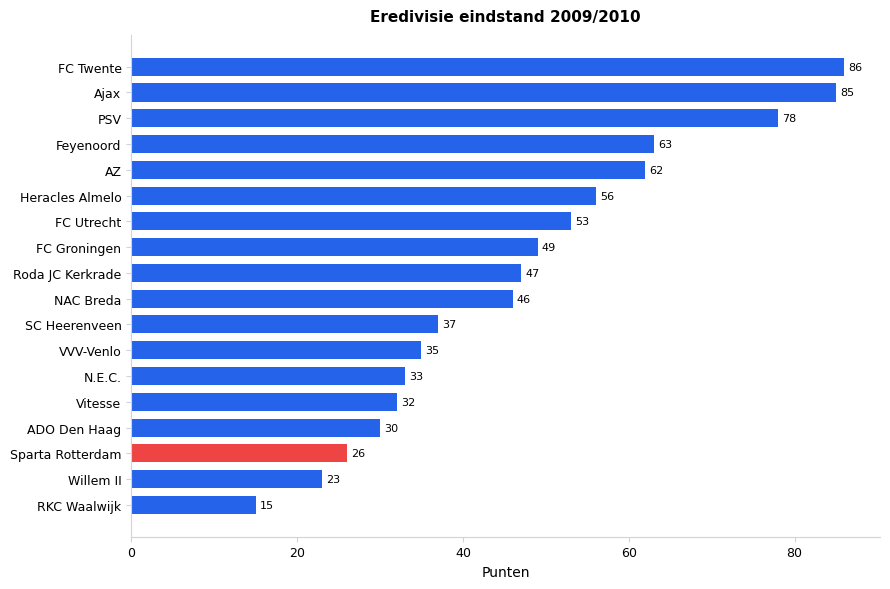

In [30]:
# Haal ranglijst op via de bestaande Research-klasse
ranking_df = Onderzoek.get_season_ranking(matches, season='2009/2010', league_id=13274)

fig, ax = plt.subplots(figsize=(9, 6))

# Kleur Sparta rood, rest blauw
colors = [RED if naam == 'Sparta Rotterdam' else BLUE for naam in ranking_df['club']]

ax.barh(ranking_df['club'][::-1], ranking_df['points'][::-1], color=colors[::-1], height=0.7)

ax.set_xlabel('Punten')
ax.set_title('Eredivisie eindstand 2009/2010', fontweight='bold')
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(color='#CBD5E1')

# Puntlabels
for i, (pts, club) in enumerate(zip(ranking_df['points'][::-1], ranking_df['club'][::-1])):
    ax.text(pts + 0.5, i, str(pts), va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 5.2 Doelpunten voor en tegen per team

Hieronder zien we voor elk team het aantal gescoorde én tegengekomen doelpunten. Ajax valt op door een extreem hoog aantal gemaakte doelpunten (106!), terwijl de verdediging van RKC Waalwijk het meest werd overlopen (80 tegendoelpunten).
Sparta Rotterdam scoorde slechts 30 doelpunten – het laagste van de competitie.

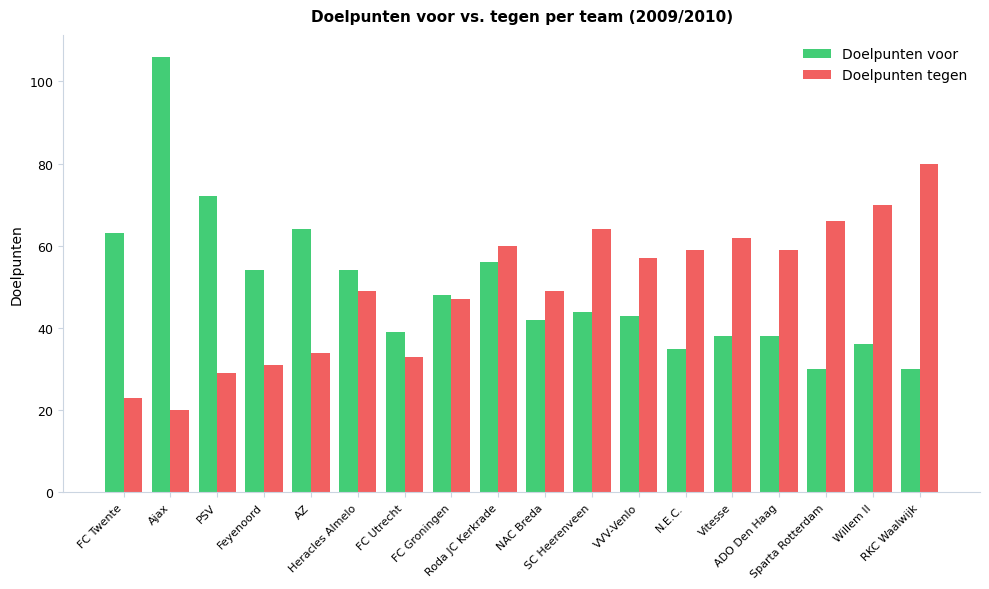

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(ranking_df))
w = 0.4

ax.bar(x - w/2, ranking_df['goals_for'],  width=w, color=GREEN,  label='Doelpunten voor',  alpha=0.85)
ax.bar(x + w/2, ranking_df['goals_against'], width=w, color=RED, label='Doelpunten tegen', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ranking_df['club'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Doelpunten')
ax.set_title('Doelpunten voor vs. tegen per team (2009/2010)', fontweight='bold')
ax.legend()
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(color='#CBD5E1')

plt.tight_layout()
plt.show()

### 5.3 Win / Gelijkspel / Verlies per team

Dit gestapelde staafdiagram geeft een duidelijk beeld van hoe elke club zijn wedstrijden eindigde. FC Twente en Ajax hadden de meeste overwinningen. RKC Waalwijk verloor maar liefst 29 van de 34 wedstrijden.
Feyenoord valt op door een relatief groot aantal gelijke spelen.

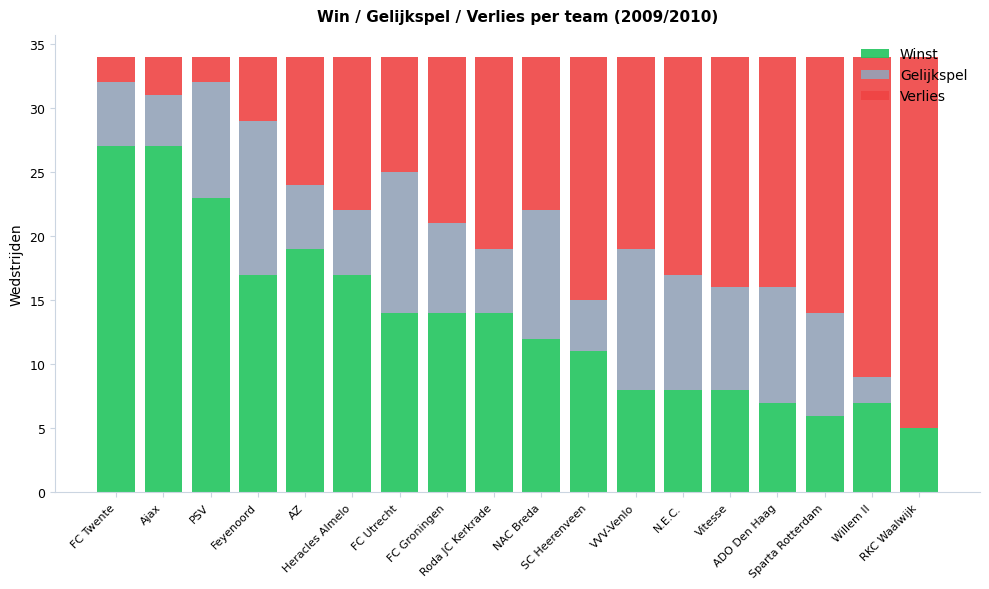

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(ranking_df))

ax.bar(x, ranking_df['wins'],   color=GREEN,  label='Winst',      alpha=0.9)
ax.bar(x, ranking_df['draws'],  color=GREY,   label='Gelijkspel', alpha=0.9, bottom=ranking_df['wins'])
ax.bar(x, ranking_df['losses'], color=RED,    label='Verlies',    alpha=0.9,
       bottom=ranking_df['wins'] + ranking_df['draws'])

ax.set_xticks(x)
ax.set_xticklabels(ranking_df['club'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Wedstrijden')
ax.set_title('Win / Gelijkspel / Verlies per team (2009/2010)', fontweight='bold')
ax.legend()
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(color='#CBD5E1')

plt.tight_layout()
plt.show()